In [7]:
import torch
import os
import re

## Dataset

In [8]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [10]:
# Read dataset dir from the log file in the experiment path
import ast
import pandas as pd


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
df.to_csv("delete_afterwards/concept_names_new_idx_map.csv", index=False)
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")





,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


In [ ]:
def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="CUB", return_c_auroc=False, return_auroc=False):
    experiment_path = os.path.join("experiments", model_type, dataset)
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []
    y_auroc_list = []
    c_auroc_list = []

    with open(os.path.join(experiment_path, model_dir, "intervention_log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Intervention on" in line and "y_accuracy" in line and "c_accuracy" in line:
                m = re.search(r"Intervention on (\d+) concepts", line)
                if not m:
                    continue
                concepts_intervened = int(m.group(1))

                y_m = re.search(r"y_accuracy:\s*([0-9.]+)", line)
                c_m = re.search(r"c_accuracy:\s*([0-9.]+)", line)
                y_auroc_m = re.search(r"y_AUROC:\s*([0-9.]+)", line)
                c_auroc_m = re.search(r"c_AUROC:\s*([0-9.]+)", line)

                y_accuracy = float(y_m.group(1)) * 100 if y_m else None
                c_accuracy = float(c_m.group(1)) * 100 if c_m else None
                y_auroc = float(y_auroc_m.group(1)) * 100 if y_auroc_m else None
                c_auroc = float(c_auroc_m.group(1)) * 100 if c_auroc_m else None

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
                y_auroc_list.append(y_auroc)
                c_auroc_list.append(c_auroc)
    if return_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, y_auroc_list, c_auroc_list
    if return_c_auroc:
        return concepts_intervened_list, y_accuracies_list, c_accuracies_list, c_auroc_list
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list

In [ ]:
scbm_model = "Mateo_025_2026-08-11_12-42-07_1357b"

# Without L_int_extension_loss
res_scbm_20_residuals_without_L_int_extension_loss = "Mateo_025_fixed_residuals_20_2026-08-13_16-06-32_a9023"

# All models have L_int_extension_loss_weight_1
res_scbm_50_residuals = "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02"

res_scbm_20_residuals = "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5"

res_scbm_5_residuals = "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-07-31_20-15-47_496cf"

cbm_model = "Mateo_025_2026-08-03_20-58-31_fe8e0"

cbm_res_model = "Mateo_025_2026-08-06_16-24-27_dd094"




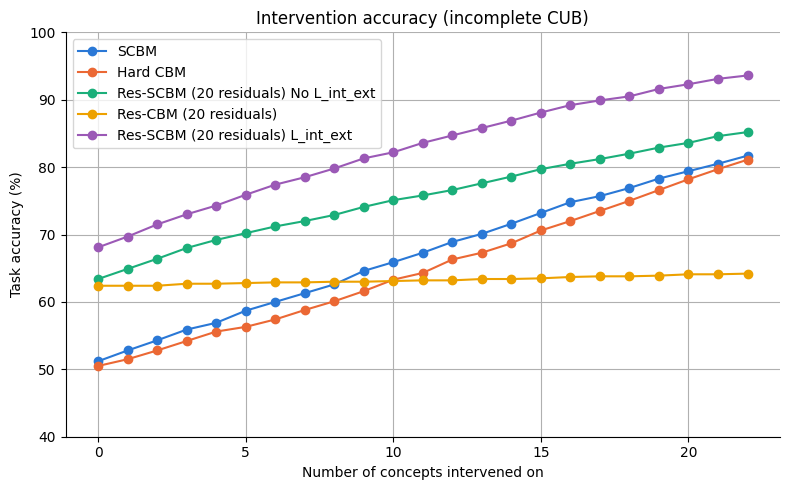

In [ ]:
import matplotlib.pyplot as plt

# (label, model_dir, model_type) -- model_type selects the experiments/<model_type>/CUB/ subfolder
models = [
    ("SCBM", scbm_model, "scbm"),
    ("Hard CBM", cbm_model, "cbm"),
    ("Res-SCBM (20 residuals) No L_int_ext", res_scbm_20_residuals_without_L_int_extension_loss, "scbm_residual"),
    ("Res-CBM (20 residuals)", cbm_res_model, "cbm_residual"),
    #("Res-SCBM (50 residuals) L_int_ext", res_scbm_50_residuals, "scbm_residual"),
    ("Res-SCBM (20 residuals) L_int_ext", res_scbm_20_residuals, "scbm_residual"),
    #("Res-SCBM (5 residuals) L_int_ext", res_scbm_5_residuals, "scbm_residual"),
]
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9b59b6", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 5))
for (label, model_dir, model_type), color in zip(models, colors):
    concepts_intervened, y_accuracies, c_accuracies = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="CUB"
    )
    ax.plot(concepts_intervened, y_accuracies, marker="o", color=color, label=label)

ax.set_xlabel("Number of concepts intervened on")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("Intervention accuracy (incomplete CUB)")
ax.legend()
ax.grid(True)
# y_max = 100
ax.set_ylim(40, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Create dataframe for the results
import pandas as pd

# columns: model_name, num_concepts_intervened, y_accuracy, c_accuracy, y_auroc, c_auroc
# Only include 0, 11, and 22 concepts intervened
keep_concepts = {0, 11, 22}

rows = []
for label, model_dir, model_type in models:
    concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs = extract_info_from_intervention_log(
        model_dir, model_type=model_type, dataset="CUB", return_auroc=True
    )
    for n, y_acc, c_acc, y_auroc, c_auroc in zip(concepts_intervened, y_accuracies, c_accuracies, y_aurocs, c_aurocs):
        if n not in keep_concepts:
            continue
        rows.append({
            "model_name": label,
            "num_concepts_intervened": n,
            "y_accuracy": y_acc,
            "c_accuracy": c_acc,
            "y_auroc": y_auroc,
            "c_auroc": c_auroc,
        })

df = pd.DataFrame(rows, columns=["model_name", "num_concepts_intervened", "y_accuracy", "c_accuracy", "y_auroc", "c_auroc"])
df

,model_name,num_concepts_intervened,y_accuracy,c_accuracy,y_auroc,c_auroc
0,SCBM,0,51.2,94.3,96.8,96.9
1,SCBM,11,67.3,97.8,99.4,99.4
2,SCBM,22,81.7,100.0,99.9,100.0
3,CBM,0,50.5,94.2,96.7,96.8
4,CBM,11,64.3,97.1,99.3,99.2
5,CBM,22,81.1,100.0,99.9,100.0
6,Res-SCBM (20 residuals) No L_int_ext,0,63.4,94.6,98.4,97.3
7,Res-SCBM (20 residuals) No L_int_ext,11,75.8,97.9,99.5,99.6
8,Res-SCBM (20 residuals) No L_int_ext,22,85.2,100.0,99.9,100.0
9,Res-CBM (20 residuals),0,62.4,94.3,97.7,97.0


## Covariance matrices

In [ ]:
import torch
cov_matrices = torch.load("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/experiments/scbm_residual/CUB/Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5/test/covariance_matrices.pt")

cov_matrices.shape

torch.Size([5794, 42, 42])

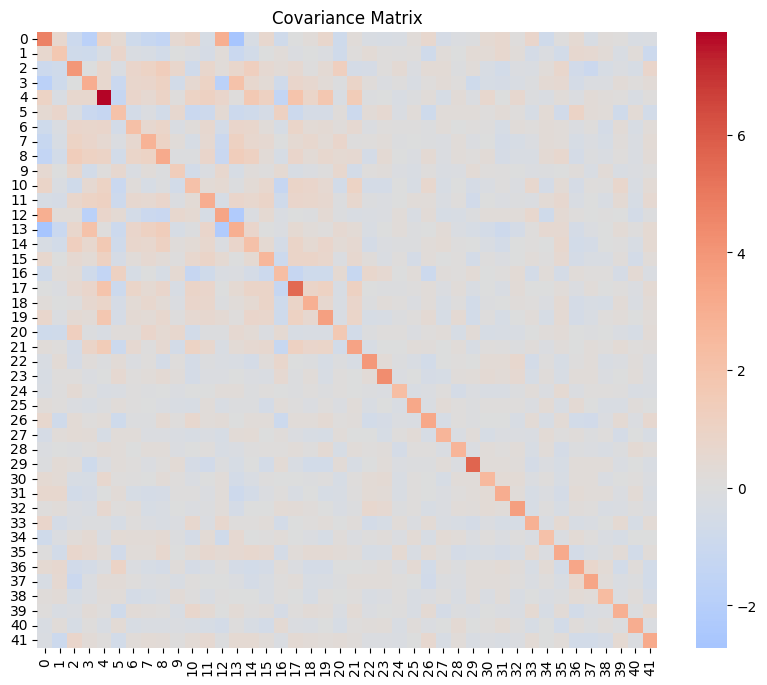

In [ ]:
# Heatmap of first covariance matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrices[0], annot=False, cmap="coolwarm", center=0)
plt.title("Covariance Matrix")
plt.show()